#### Using https://earthdatascience.org/courses/use-data-open-source-python/intro-raster-data-python/raster-data-processing/reproject-raster/

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from shapely.geometry import box
import geopandas as gpd


In [ ]:
basin = gpd.read_file("C:/Users/RDCRLSMC/Desktop/SIRO/data/MCS_outline/basin_outline.shp")
lidar = gpd.read_file("C:/Users/RDCRLSMC/Desktop/GIS/MCS/MCS_shp/MCS_outline.shp")

In [ ]:
# Plot the clipped data
f, ax = plt.subplots(figsize=(10, 4))

basin.plot(ax=ax,
                       edgecolor="blue",
                       color="white")

ax.set(title="MSC Basin")
plt.show()

In [ ]:
buffer_distance = 7000 # Example: 100 units (e.g., meters if in EPSG:3857)
basin_buffered = basin.copy() # Create a copy to avoid modifying original
basin_buffered['geometry'] = basin_buffered['geometry'].buffer(buffer_distance)

In [ ]:
# Suppose you have a polygon (or GeoSeries)
xmin,ymin,xmax,ymax =  basin_buffered.total_bounds
print(xmin,ymin,xmax,ymax)
# convert to polygon
geom =box(*basin_buffered.total_bounds)
x_ext, y_ext = geom.exterior.xy

print(f"Bounds: {xmin}, {ymin}, {xmax}, {ymax}")



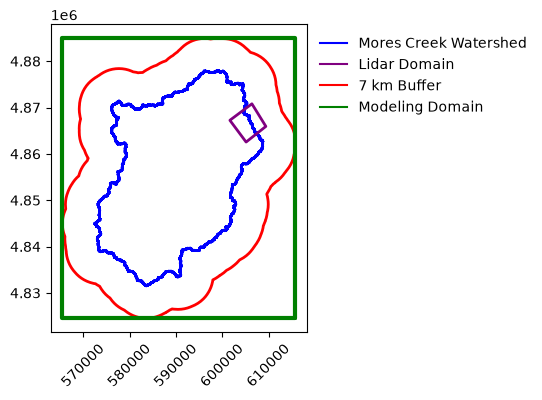

In [16]:

#plot buffer
f, ax = plt.subplots(figsize=(10, 4))

basin.plot(ax=ax, edgecolor="blue", facecolor="none", linewidth=2, label="Mores Creek Watershed")
basin_buffered.plot(ax=ax, edgecolor="red", facecolor="none", linewidth=2, label="7 km Buffer")
ax.plot(x_ext, y_ext, color='green', linewidth=3, solid_capstyle='round', zorder=1, label = "Clipping boundary")
lidar.plot(ax=ax,edgecolor="purple", facecolor="none", linewidth=2, label="Lidar Domain")


blue_line = mlines.Line2D([], [], color='blue', label='Mores Creek Watershed')
red_line = mlines.Line2D([], [], color='red', label='7 km Buffer')
green_line = mlines.Line2D([], [], color='green', label='Modeling Domain')
purple_line = mlines.Line2D([], [], color='purple', label='Lidar Domain')
plt.xticks(rotation=45)

ax.legend(
    handles=[blue_line, purple_line, red_line, green_line],
    loc='upper left',  # position relative to bbox
    bbox_to_anchor=(1, 1),  # (x, y): 1 means right edge of plot
    frameon=False
)

plt.show()

In [ ]:
from pathlib import Path

home_dir = Path(".") / "SIRO"
out_dir = home_dir / "GIS" / "reproject"
out_dir.mkdir(parents=True, exist_ok=True)


In [ ]:
##EVT
cmd = [
    "gdalwarp",
    "-t_srs", "EPSG:32611",
    "-te", str(xmin), str(ymin), str(xmax), str(ymax),
    "-r", "near",
    "-co", "COMPRESS=LZW",
    "-co", "TILED=YES",
    "-co", "BIGTIFF=YES",   # handle large files
    str(home_dir / "LF2022_EVT_230_CONUS/LF2022_EVT_230_CONUS/Tif/LC22_EVT_230.tif"),
    str(out_dir / "LC22_EVT_230.tif")]

print(" ".join(cmd))

In [ ]:
##DEM
cmd = [
    "gdalwarp",
    "-t_srs", "EPSG:32611",
    "-te", str(xmin), str(ymin), str(xmax), str(ymax),
    "-r", "near",
    "-co", "COMPRESS=LZW",
    "-co", "TILED=YES",
    "-co", "BIGTIFF=YES",   # handle large files
    str(home_dir / "GIS/merged.tif"),
    str(out_dir / "DEM.tif")]

print(" ".join(cmd))

In [ ]:
##FH
cmd = [
    "gdalwarp",
    "-t_srs", "EPSG:32611",
    "-te", str(xmin), str(ymin), str(xmax), str(ymax),
    "-r", "near",
    "-co", "COMPRESS=LZW",
    "-co", "TILED=YES",
    "-co", "BIGTIFF=YES",   # handle large files
    str(home_dir / "GIS/Forest_height_2019_NAM.tif"),
    str(out_dir / "Forest_height_2019_NAM.tif")]

print(" ".join(cmd))